In [1]:
from kg.query import query_kg, query_kg_endpoint, get_triples_from_response
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import os

In [2]:
from utils.kg_functions import load_json, extract_ids_with_prefix, convert_QID_yagoID
from utils.kg_functions import combine_lists_from_dict, get_yago_direct_neighbors, sparql_to_triples_with_main_entity
from utils.kg_functions import parallel_process_nodes, extract_ids_with_prefix, parallel_convert_QID_yagoID
from utils.helper_functions import decode_underscored_unicode
from utils.prompts import gen_qa_prompt

# from utils.subgraph_functions import create_graph_from_triples, build_minimal_subgraph_Steiner, largest_connected_subgraph
# from utils.subgraph_functions import plot_graph_with_simplified_labels, get_interesting_entities, filter_triples_by_predicates
from utils.subgraph_functions import (create_graph_from_triples, build_minimal_subgraph_Steiner, plot_full_graph,
                                      largest_connected_subgraph, edges_to_triples, plot_graph_with_simplified_labels,
                                      get_interesting_entities, filter_triples_by_predicates, prune_triples)
from utils.wiki_ner import extract_entities_to_json

In [3]:

exclude_props = ['knowsLanguage', 'location', 'image', 'about', 'comment', 'gtin', 'url', 'label', 
                 'postalCode', 'isbn', 'sameAs', 'mainEntityOfPage', 'leiCode', 'type', 'dateCreated', 
                 'unemploymentRate', 'length', 'description', 'iswcCode', 'iataCode', 'logo', 'alternateName', 
                 'geo', 'subclassOf', 'icaoCode', 'humanDevelopmentIndex', 'sameAs', 'dateCreated', 
                 'startDate', 'endDate', 'follows', 'superEvent']

In [4]:
def process_qid(QID, entities):
    try:
        # logging.info(f"Processing QID: {QID}")
        
        interesting_entities = get_interesting_entities(QID, entities)
        results = parallel_process_nodes(interesting_entities)
        comb_list_large = combine_lists_from_dict(results)
        comb_list = filter_triples_by_predicates(comb_list_large, exclude_props)
        graph = create_graph_from_triples(comb_list)

        subgraph_Steiner = build_minimal_subgraph_Steiner(graph, interesting_entities)
        subgraph_Steiner_largest_connected = largest_connected_subgraph(subgraph_Steiner)

        subgraph_Steiner_triples = edges_to_triples(subgraph_Steiner)
        subgraph_Steiner_largest_connected_triples = edges_to_triples(subgraph_Steiner_largest_connected)

        result = {
            'subgraph_Steiner': subgraph_Steiner_triples,
            'subgraph_Steiner_length': len(subgraph_Steiner_triples),
            'subgraph_Steiner_largest_connected': subgraph_Steiner_largest_connected_triples,
            'subgraph_Steiner_largest_connected_length': len(subgraph_Steiner_largest_connected_triples)
        }

        # logging.info(f"Finished processing QID: {QID}")
        return QID, result, interesting_entities, comb_list_large

    except Exception as e:
        print(f"Error processing QID {QID}: {e}")
        return QID, None

In [5]:
# text = 'What family does the alpaca belong to, considering its evolutionary lineage through its parent taxa? Camelidae'
text = '''
The **Camelidae** family, which includes species such as **camels**, **alpacas**, **llamas**, **guanacos**, and **vicuñas**, belongs to the broader taxonomic group of **even-toed ungulates** (*Artiodactyla*). This classification places them alongside other members of the **Ungulate** clade. Within Camelidae, the **Lama** genus includes **llamas** and **guanacos**, while the **Vicugna** genus encompasses **vicuñas** and **alpacas**.

Similarly, **Tylopoda**, another subgroup within even-toed ungulates, shares ancestry with other ruminant species. The **Chevrotain**, also known as the mouse-deer, falls under **Tragulina**, a suborder of **ruminants**, distinguishing them from their relatives in the **Pecora** group. 

Meanwhile, **Suina**, another branch of even-toed ungulates, consists of animals like pigs and peccaries, diverging from Camelidae and other ruminants. The evolutionary links between these groups highlight their diverse adaptations while maintaining a common lineage within **Artiodactyla**.
'''

In [6]:
# text = ''' 
# The Camelidae family includes camels, alpacas, llamas, guanacos, and vicuñas, which are well-adapted to various environments. Within Camelidae, the Lama genus consists of llamas and guanacos, while the Vicugna genus includes vicuñas and alpacas. These species have played an essential role in human culture and economy for centuries.

# Similarly, the Chevrotain, often referred to as a mouse-deer, belongs to a distinct lineage and shares ancestry with other ungulates. While it differs significantly in size and ecological niche from the larger camelids, it retains certain evolutionary traits that link it to the broader classification of hoofed mammals.
# '''

In [23]:
# text = '''
# Hideki Kamiya has made significant contributions to the gaming industry, working with leading developers and shaping iconic titles. Stride (game engine) emerged as a remarkable tool in game development. PlayStation Vita revolutionized handheld gaming, offering immersive experiences to players worldwide. Yuji Naka played a pivotal role in shaping game design, contributing to some of the most beloved franchises. Bravely Default redefined the RPG genre with its innovative mechanics and storytelling. FromSoftware has consistently delivered challenging and rewarding experiences to gamers. Jun Yoshino’s expertise in production and development has influenced various successful projects. Sakura Wars: So Long, My Love remains a cherished title among fans of tactical RPGs. PlayStation stands as one of the most influential gaming brands in history. Rise of Incarnates introduced a unique approach to competitive fighting games, leaving a lasting impact.
# '''

In [5]:
text = '''
Sega has been a powerhouse in game development, responsible for shaping the industry with legendary franchises. Bandai Namco Entertainment continues to innovate, producing unforgettable games that resonate with players globally. Silicon Studio stands out for its contributions to game engines and development tools. Sony Interactive Entertainment has played a major role in gaming history, pioneering advancements in console technology. Square Enix is known for its mastery in storytelling and immersive worlds, defining the RPG genre. Idea Factory has contributed to the gaming industry with its focus on niche genres and creative storytelling.
'''

In [6]:
_ ,entities = extract_entities_to_json(text)

In [31]:
# entities#[0]#['id']

[{'id': 122741,
  'label': 'Sega',
  'description': 'Japanese video game developer and publisher and subsidiary of Sega Sammy Holdings',
  'span': 'Sega',
  'url': 'https://www.wikidata.org/wiki/Q122741'},
 {'id': 159719,
  'label': 'power station',
  'description': 'facility generating electric power',
  'span': 'powerhouse',
  'url': 'https://www.wikidata.org/wiki/Q159719'},
 {'id': 1061635,
  'label': 'video game development',
  'description': 'process of creating a computer or video game',
  'span': 'game development',
  'url': 'https://www.wikidata.org/wiki/Q1061635'},
 {'id': 8148,
  'label': 'industry',
  'description': 'production of goods or service of a given field within an economy',
  'span': 'industry',
  'url': 'https://www.wikidata.org/wiki/Q8148'},
 {'id': 196600,
  'label': 'media franchise',
  'description': 'use of a creative work across several different media',
  'span': 'franchises',
  'url': 'https://www.wikidata.org/wiki/Q196600'},
 {'id': 1194689,
  'label': 'B

In [7]:
qid, res, interesting_nodes, large_graph = process_qid('Q122741', entities)

In [8]:
print(len(res['subgraph_Steiner']), len(large_graph))

# res['subgraph_Steiner']

10 1191


In [10]:
interesting_nodes

['http://yago-knowledge.org/resource/Game_engine',
 'http://yago-knowledge.org/resource/Expertise',
 'http://yago-knowledge.org/resource/Sega',
 'http://yago-knowledge.org/resource/Programming_tool',
 'http://yago-knowledge.org/resource/Hideki_Kamiya',
 'http://yago-knowledge.org/resource/Contribution__u0028_album_u0029_',
 'http://yago-knowledge.org/resource/Bandai_Namco_Entertainment',
 'http://yago-knowledge.org/resource/Media_franchise',
 'http://yago-knowledge.org/resource/Idea_Factory',
 'http://yago-knowledge.org/resource/Gamer',
 'http://yago-knowledge.org/resource/Power_station',
 'http://yago-knowledge.org/resource/Silicon_Studio',
 'http://yago-knowledge.org/resource/Square_Enix',
 'http://yago-knowledge.org/resource/Advancement__u0028_inheritance_u0029_',
 'http://yago-knowledge.org/resource/Game',
 'http://yago-knowledge.org/resource/Industry__u0028_manufacturing_u0029_',
 'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment',
 'http://yago-knowledge.org/reso

In [10]:
g = create_graph_from_triples(res['subgraph_Steiner'])
# plot_graph_with_simplified_labels(g)

['http://yago-knowledge.org/resource/Sega',
 'http://yago-knowledge.org/resource/Square_Enix',
 'http://yago-knowledge.org/resource/Hideki_Kamiya',
 'http://yago-knowledge.org/resource/Bandai_Namco_Entertainment',
 'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment',
 'http://yago-knowledge.org/resource/Silicon_Studio',
 'http://yago-knowledge.org/resource/Idea_Factory']

In [13]:
int_nodes_present = plot_graph_with_simplified_labels(g,layout_type='shell', interesting_nodes=interesting_nodes)

TypeError: plot_graph_with_simplified_labels() got an unexpected keyword argument 'interesting_nodes'

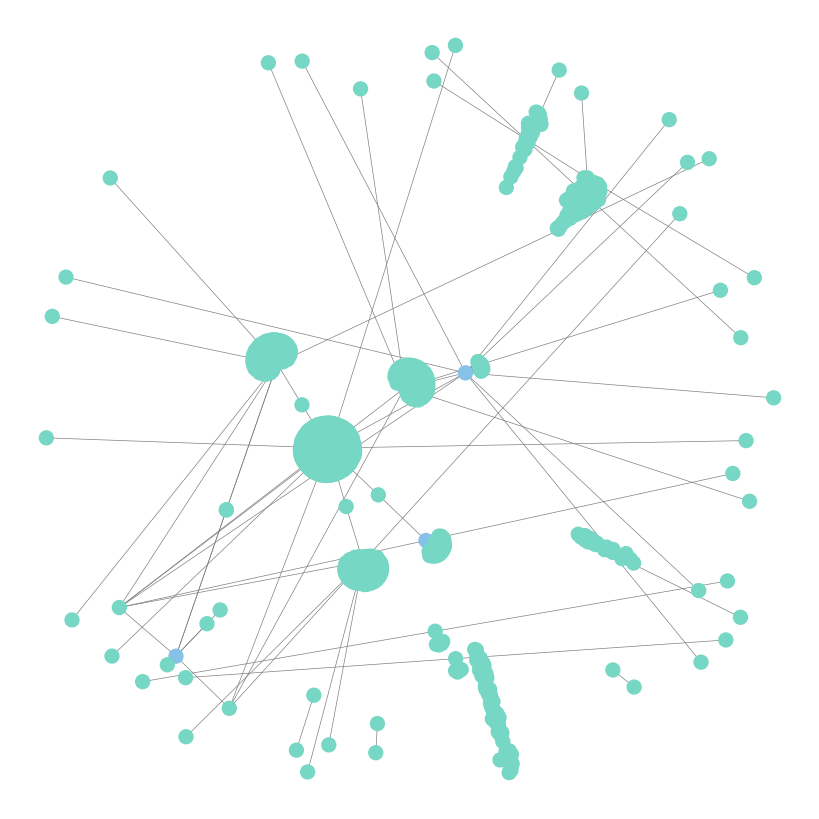

In [147]:
full_g = create_graph_from_triples(large_graph)
plot_full_graph(full_g, interesting_entities=list(int_nodes_present), layout_type='spring', figsize=(8, 8))

In [57]:
# def plot_full_graph(graph, interesting_entities):
#     # Assign colors based on whether a node is in interesting_nodes
#     node_colors = [
#         "#FF5733" if node in interesting_entities else "skyblue"
#         for node in graph.nodes()
#     ]
    

#     # Draw the graph with labels and highlighted nodes
#     plt.figure(figsize=(10, 8))
#     pos = nx.spring_layout(graph)  # Layout for nodes
#     nx.draw(graph, pos, node_size=300, node_color=node_colors, arrowsize=10, edge_color="gray")
#     plt.show()

In [146]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_full_graph(graph, interesting_entities=None, layout_type="spring", figsize=(10, 10), node_size=100, edge_width=0.5):
    """
    Plot a large graph without text labels while controlling layout and size.

    Parameters:
    - graph: NetworkX graph
    - interesting_entities: List of nodes to highlight
    - layout_type: Graph layout ("spring", "shell", "circular", "kamada_kawai", "spectral")
    - figsize: Tuple specifying figure size
    - node_size: Size of the nodes
    - edge_width: Width of the edges
    """

    # Determine layout
    if layout_type == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        pos = nx.shell_layout(graph)
    elif layout_type == "circular":
        pos = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        pos = nx.spectral_layout(graph)
    else:
        pos = nx.spring_layout(graph, seed=42)  # Default to spring layout

    # Assign colors based on whether a node is in interesting_entities
    node_colors = [
        "#85c1e9" if node in (interesting_entities or []) else "#76d7c4"
        for node in graph.nodes()
    ]

    # Draw the graph
    plt.figure(figsize=figsize)
    nx.draw(graph, pos, node_size=node_size, node_color=node_colors, edge_color="gray", width=edge_width, arrows=False)
    
    plt.axis("off")
    plt.margins(0)
    # plt.show()
    plt.savefig('/home/ubuntu/preetam_experiments/plots/graph3_full_neighborhood.pdf', format='pdf', dpi=300, bbox_inches='tight')

    
    


In [14]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_graph_with_simplified_labels_steps(graph, title="Graph Visualization", figsize=(8, 8), 
                                      layout_type=None, interesting_nodes=None, node_type_colors=None):
    """
    Generate two plots: one with all nodes and another with only the interesting nodes.
    
    Parameters:
    - graph: NetworkX graph
    - title: Title for the plot
    - figsize: Tuple specifying figure size
    - layout_type: Explicit layout choice ("spring", "shell", "circular", "kamada_kawai", "spectral")
    - interesting_nodes: List of nodes to highlight with a different color
    - node_type_colors: Dictionary mapping node types to specific colors
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()

    # Determine layout
    if layout_type == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        pos = nx.shell_layout(graph)
    elif layout_type == "circular":
        pos = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        pos = nx.spectral_layout(graph)
    else:
        if num_nodes < 10:
            pos = nx.shell_layout(graph)
        elif num_edges > num_nodes * 2:
            pos = nx.circular_layout(graph)
        elif nx.is_tree(graph):
            pos = nx.kamada_kawai_layout(graph)
        else:
            pos = nx.spring_layout(graph, seed=42)

    # Simplify node labels
    node_labels = {node: decode_underscored_unicode(node.split('/')[-1]).replace(' ', '\n') for node in graph.nodes()}

    # Simplify edge labels
    edge_labels = {
        (u, v): decode_underscored_unicode(data['relation'].split('/')[-1])
        for u, v, data in graph.edges(data=True)
    }

    ### Plot 1: Graph with ONLY interesting nodes
    if interesting_nodes:
        subgraph = graph.subgraph(interesting_nodes)  # Extract subgraph of interesting nodes

        plt.figure(figsize=figsize)
        
        # Assign colors: Highlight interesting nodes
        node_colors = ["#85c1e9" if node in interesting_nodes else " #76d7c4" for node in subgraph.nodes()] #"#D3D3D3"

        # Draw the interesting nodes graph
        nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=2500, edgecolors='black')
        # nx.draw_networkx_edges(subgraph, pos, alpha=0.6, width=2, edge_color="gray", arrows=True)
        # nx.draw_networkx_labels(subgraph, pos, labels=node_labels, font_size=10, font_weight="bold")
        interesting_font_color="black"
        non_interesting_font_color="white"
        for node in subgraph.nodes():
            color = interesting_font_color if node in interesting_nodes else non_interesting_font_color
            nx.draw_networkx_labels(subgraph, pos, labels={node: node_labels[node]}, 
                                    font_size=10, font_weight="bold", font_color=color)


        # Draw edge labels
        # subgraph_edge_labels = {edge: edge_labels[edge] for edge in subgraph.edges() if edge in edge_labels}
        # nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=subgraph_edge_labels, font_size=8)

        # plt.title(f"{title} (Filtered: Interesting Nodes)", fontsize=14, fontweight="bold")
        plt.axis("off")
        plt.margins(0.15)
        # plt.show()
        #save as pdf with high resolution
        plt.savefig('/home/ubuntu/preetam_experiments/plots/graph1_interestingNodes.pdf', format='pdf', dpi=300, bbox_inches='tight')
        
    ### Plot 2: Graph with ONLY interesting nodes with edges
    if interesting_nodes:
        subgraph = graph.subgraph(interesting_nodes)  # Extract subgraph of interesting nodes

        plt.figure(figsize=figsize)
        
        # Assign colors: Highlight interesting nodes
        # node_colors = ["green" if node in interesting_nodes else "skyblue" for node in subgraph.nodes()] #"#D3D3D3"      

        # Draw the interesting nodes graph
        nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=2500, edgecolors='black')
        nx.draw_networkx_edges(subgraph, pos, alpha=0.6, width=2, edge_color="gray", arrows=True)
        # nx.draw_networkx_labels(subgraph, pos, labels=node_labels, font_size=10, font_weight="bold")
        interesting_font_color="black"
        non_interesting_font_color="white"
        for node in subgraph.nodes():
            color = interesting_font_color if node in interesting_nodes else non_interesting_font_color
            nx.draw_networkx_labels(subgraph, pos, labels={node: node_labels[node]}, 
                                    font_size=10, font_weight="bold", font_color=color)


        # Draw edge labels
        subgraph_edge_labels = {edge: edge_labels[edge] for edge in subgraph.edges() if edge in edge_labels}
        nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=subgraph_edge_labels, font_size=8)

        # plt.title(f"{title} (Filtered: Interesting Nodes)", fontsize=14, fontweight="bold")
        plt.axis("off")
        plt.margins(0.15)
        # plt.show()
        plt.savefig('/home/ubuntu/preetam_experiments/plots/graph2_interestingNodes_wEdges.pdf', format='pdf', dpi=300, bbox_inches='tight')

    ### Plot 3: Full Graph
    plt.figure(figsize=figsize)

    # Assign node colors for full graph
    # default_color = "skyblue"#"#D3D3D3"
    # highlight_color = "green"
    highlight_color = "#85c1e9"
    default_color = "#76d7c4"
    node_colors = []
    
    for node in graph.nodes():
        if interesting_nodes and node in interesting_nodes:
            node_colors.append(highlight_color)
        elif node_type_colors and node in node_type_colors:
            node_colors.append(node_type_colors[node])
        else:
            node_colors.append(default_color)

    # Draw full graph
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=2500, edgecolors='black')
    nx.draw_networkx_edges(graph, pos, alpha=0.6, width=2, edge_color="gray", arrows=True)
    nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=10,  font_weight="bold")

    # Draw edge labels
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8)

    # plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.margins(0.1)
    # plt.show()
    plt.savefig('/home/ubuntu/preetam_experiments/plots/graph4_interestingNodes_full.pdf', format='pdf', dpi=300, bbox_inches='tight')

    
    return subgraph.nodes()


In [149]:
readable_triples = prune_triples(res['subgraph_Steiner'])
prompt = gen_qa_prompt(readable_triples)

In [151]:
print(prompt)

You are an AI assistant tasked with generating question-answer pairs from knowledge graph triples. Your goal is to create natural, human-like questions and their corresponding answers based on the provided graph data.

Task Overview:
Generate **multi-hop, complex Q&A pairs** where the questions appear simple and natural but require reasoning across multiple connected relationships within the graph to infer the answer.

Guidelines for Generating Q&A Pairs:
1. **Question Design**:
- Questions should utilize multiple connected relationships in the graph, requiring multi-hop reasoning.
- Avoid single-hop or trivial questions directly derived from a single triple.
- The answer should be an entity or node in the graph.

2. **Multi-Hop Reasoning**:
- Use paths connecting entities indirectly through multiple relationships to infer answers.
- Questions should reflect meaningful and interesting connections within the graph.
- Aim for question with at least 4 hops or higher whenever possible.

3.

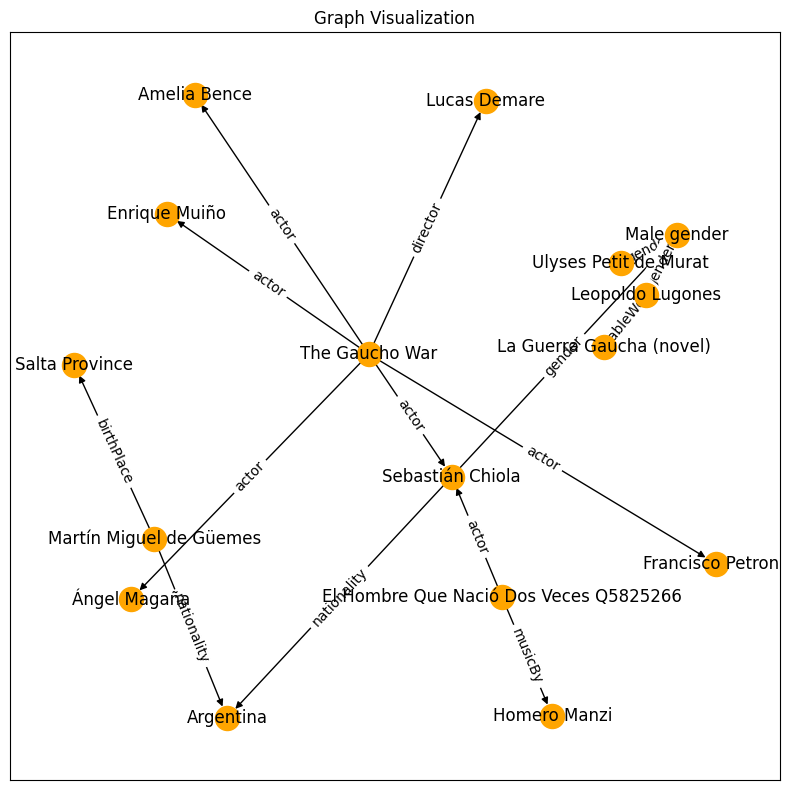

In [37]:
g = create_graph_from_triples(subg)
plot_graph_with_simplified_labels(g, layout_type='spring')

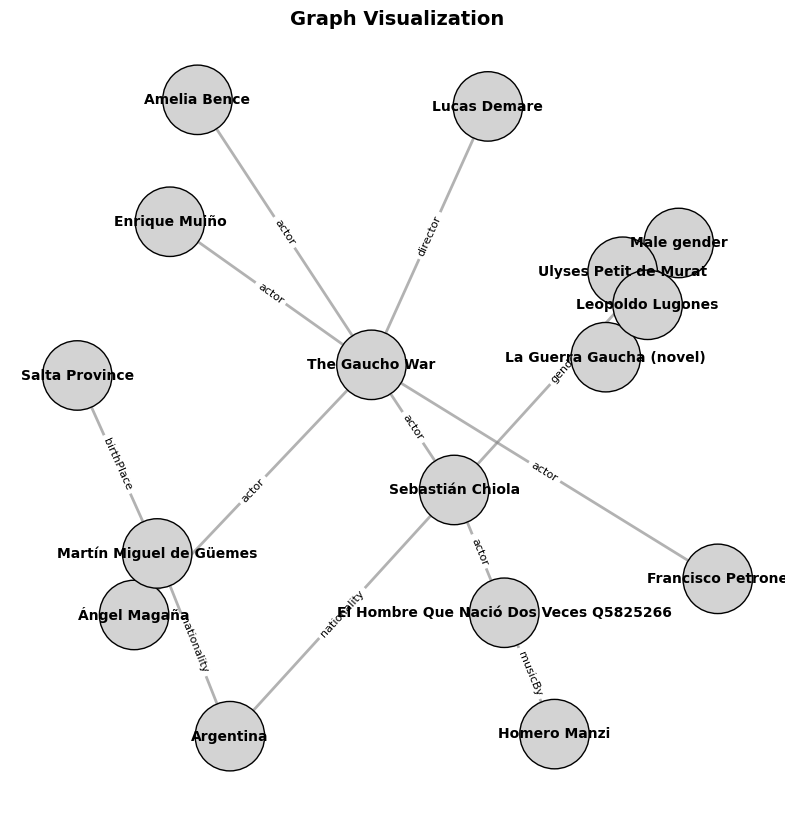

In [18]:
g = create_graph_from_triples(subg)
plot_graph_with_simplified_labels(g, layout_type='spring')

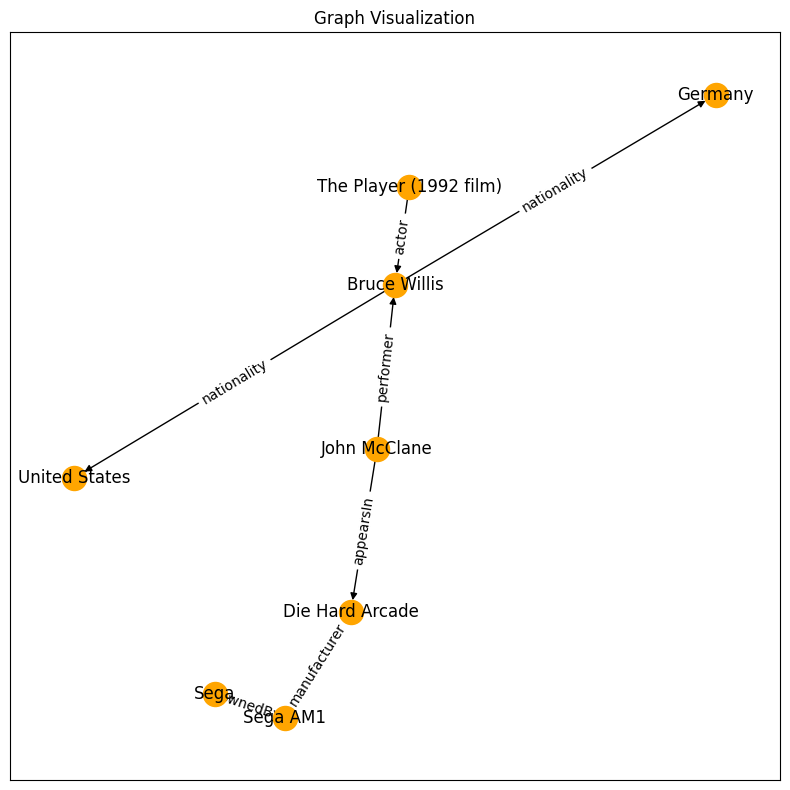

In [48]:
g = create_graph_from_triples(subg)
plot_graph_with_simplified_labels(g, layout_type='spring')

In [7]:

def plot_graph_with_simplified_labels(graph, title="Graph Visualization", figsize=(8, 8), layout_type=None):
    """
    Plot a graph with node and edge labels simplified to text after the last '/'.

    Parameters:
    - graph: NetworkX graph
    - title: Title for the plot
    """
    # Determine layout dynamically based on graph size
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    
    

    # Determine layout
    if layout_type == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        pos = nx.shell_layout(graph)
    elif layout_type == "circular":
        pos = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        pos = nx.spectral_layout(graph)
    else:
        if num_nodes < 10:
            pos = nx.shell_layout(graph)
        elif num_edges > num_nodes * 2:
            pos = nx.circular_layout(graph)
        elif nx.is_tree(graph):
            pos = nx.kamada_kawai_layout(graph)
        else:
            pos = nx.spring_layout(graph, seed=42)

    plt.figure(figsize=figsize)

    # Simplify node labels
    node_labels = {node: decode_underscored_unicode(node.split('/')[-1]) for node in graph.nodes()}

    # Simplify edge labels
    edge_labels = {
        (u, v): decode_underscored_unicode(data['relation'].split('/')[-1])
        for u, v, data in graph.edges(data=True)
    }

    # Get node positions
    # pos = layout_type

    # Draw the graph with simplified labels
    nx.draw_networkx(
        graph,
        pos=pos,
        labels=node_labels,
        node_color="orange",
        with_labels=True
    )

    # Draw edge labels
    nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=edge_labels)

    # Adjust axis limits dynamically to ensure all nodes/edges are visible
    x_vals, y_vals = zip(*pos.values())
    x_margin = (max(x_vals) - min(x_vals)) * 0.1  # Add 10% margin
    y_margin = (max(y_vals) - min(y_vals)) * 0.1
    plt.xlim(min(x_vals) - x_margin, max(x_vals) + x_margin)
    plt.ylim(min(y_vals) - y_margin, max(y_vals) + y_margin)

    # Add title and adjust layout
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [15]:


def plot_graph_with_simplified_labels(graph, title="Graph Visualization", figsize=(10, 10), 
                                      layout_type=None, interesting_nodes=None, node_type_colors=None):
    """
    Plot a graph with improved aesthetics.
    
    Parameters:
    - graph: NetworkX graph
    - title: Title for the plot
    - figsize: Tuple specifying figure size
    - layout_type: Explicit layout choice ("spring", "shell", "circular", "kamada_kawai", "spectral")
    - interesting_nodes: List of nodes to highlight with a different color
    - node_type_colors: Dictionary mapping node types to specific colors
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()

    # Determine layout
    if layout_type == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        pos = nx.shell_layout(graph)
    elif layout_type == "circular":
        pos = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        pos = nx.spectral_layout(graph)
    else:
        if num_nodes < 10:
            pos = nx.shell_layout(graph)
        elif num_edges > num_nodes * 2:
            pos = nx.circular_layout(graph)
        elif nx.is_tree(graph):
            pos = nx.kamada_kawai_layout(graph)
        else:
            pos = nx.spring_layout(graph, seed=42)

    plt.figure(figsize=figsize)
    
    # Simplify node labels
    node_labels = {node: decode_underscored_unicode(node.split('/')[-1]) for node in graph.nodes()}

    # Simplify edge labels
    edge_labels = {
        (u, v): decode_underscored_unicode(data['relation'].split('/')[-1])
        for u, v, data in graph.edges(data=True)
    }

    # Assign node colors based on type
    default_color = "#D3D3D3"  # Light gray for default nodes
    highlight_color = "#FF5733"  # Red for interesting nodes
    node_colors = []

    for node in graph.nodes():
        if interesting_nodes and node in interesting_nodes:
            node_colors.append(highlight_color)
        elif node_type_colors and node in node_type_colors:
            node_colors.append(node_type_colors[node])
        else:
            node_colors.append(default_color)

    # Draw graph
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=2500, edgecolors='black')
    nx.draw_networkx_edges(graph, pos, alpha=0.6, width=2, edge_color="gray", arrows=True)
    nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=10, font_weight="bold") #font_family="Arial", 

    # Draw edge labels with curved edges
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8) #font_family="Arial", 

    # Set title
    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


In [36]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_graph_with_simplified_labels(graph, title="Graph Visualization", figsize=(8, 8), 
                                      layout_type=None, interesting_nodes=None):
    """
    Plot a graph with node and edge labels simplified to text after the last '/'.
    
    Parameters:
    - graph: NetworkX graph
    - title: Title for the plot
    - figsize: Tuple specifying figure size
    - layout_type: Explicit layout choice ("spring", "shell", "circular", "kamada_kawai", "spectral")
    - interesting_nodes: List of nodes to highlight with a different color
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()

    # Determine layout based on user preference or dynamically
    if layout_type == "spring":
        layout = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        layout = nx.shell_layout(graph)
    elif layout_type == "circular":
        layout = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        layout = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        layout = nx.spectral_layout(graph)
    else:
        # Dynamic selection based on graph properties
        if num_nodes < 10:
            layout = nx.shell_layout(graph)
        elif num_edges > num_nodes * 2:
            layout = nx.circular_layout(graph)
        elif nx.is_tree(graph):
            layout = nx.kamada_kawai_layout(graph)
        else:
            layout = nx.spring_layout(graph, seed=42)

    plt.figure(figsize=figsize)

    # Simplify node labels
    node_labels = {node: decode_underscored_unicode(node.split('/')[-1]) for node in graph.nodes()}

    # Simplify edge labels
    edge_labels = {
        (u, v): decode_underscored_unicode(data['relation'].split('/')[-1])
        for u, v, data in graph.edges(data=True)
    }

    # Get node positions
    pos = layout

    # Determine node colors
    default_color = "orange"
    highlight_color = "red"
    node_colors = [highlight_color if node in (interesting_nodes or []) else default_color for node in graph.nodes()]

    # Draw the graph with simplified labels
    nx.draw_networkx(
        graph,
        pos=pos,
        labels=node_labels,
        node_color=node_colors,
        with_labels=True
    )

    # Draw edge labels
    nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=edge_labels)

    # Adjust axis limits dynamically to ensure all nodes/edges are visible
    x_vals, y_vals = zip(*pos.values())
    x_margin = (max(x_vals) - min(x_vals)) * 0.1  # Add 10% margin
    y_margin = (max(y_vals) - min(y_vals)) * 0.1
    plt.xlim(min(x_vals) - x_margin, max(x_vals) + x_margin)
    plt.ylim(min(y_vals) - y_margin, max(y_vals) + y_margin)

    # Add title and adjust layout
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [16]:
subg = [['http://yago-knowledge.org/resource/Hideki_Kamiya',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Hideki_Kamiya',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Bandai_Namco_Entertainment'],
 ['http://yago-knowledge.org/resource/Stride__u0028_game_engine_u0029_',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Silicon_Studio'],
 ['http://yago-knowledge.org/resource/PlayStation_Vita',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Yuji_Naka',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Yuji_Naka',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Square_Enix'],
 ['http://yago-knowledge.org/resource/Bravely_Default',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Square_Enix'],
 ['http://yago-knowledge.org/resource/Bravely_Default',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Silicon_Studio'],
 ['http://yago-knowledge.org/resource/FromSoftware',
  'http://yago-knowledge.org/resource/ownedBy',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Jun_Yoshino',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Jun_Yoshino',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Sakura_Wars_u003A__So_Long_u002C__My_Love',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Sakura_Wars_u003A__So_Long_u002C__My_Love',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Idea_Factory'],
 ['http://yago-knowledge.org/resource/PlayStation',
  'http://yago-knowledge.org/resource/ownedBy',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Rise_of_Incarnates',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Bandai_Namco_Entertainment']]

In [19]:
subg = [["http://yago-knowledge.org/resource/China", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Japan"], 
["http://yago-knowledge.org/resource/China", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Kyrgyzstan"], 
["http://yago-knowledge.org/resource/Japan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/China"], 
["http://yago-knowledge.org/resource/Japan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Pacific_Ocean"], 
["http://yago-knowledge.org/resource/Second_Sino-Japanese_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Republic_of_China__u0028_1912_u2013_1949_u0029_"], 
["http://yago-knowledge.org/resource/First_Indochina_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Kingdom_of_Laos"], 
["http://yago-knowledge.org/resource/Kijir\u014d_Nambu", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Japan"], 
["http://yago-knowledge.org/resource/Tomioka_u002C__Fukushima", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Pacific_Ocean"], 
["http://yago-knowledge.org/resource/Vietnam_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Viet_Cong"], 
["http://yago-knowledge.org/resource/Vietnam_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/North_Korea"], 
["http://yago-knowledge.org/resource/Vietnam_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Kingdom_of_Laos"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/China"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/North_Korea"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Canada"], 
["http://yago-knowledge.org/resource/Pacific_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Canada"], 
["http://yago-knowledge.org/resource/Pacific_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Republic_of_China__u0028_1912_u2013_1949_u0029_"], 
["http://yago-knowledge.org/resource/Kyrgyzstan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/China"], 
["http://yago-knowledge.org/resource/Emperor_Taish\u014d", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Japan"]]



In [9]:
subg = [["http://yago-knowledge.org/resource/Ottoman_Empire", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Byzantine_Empire"], ["http://yago-knowledge.org/resource/Lebanon", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Syria"], ["http://yago-knowledge.org/resource/Byzantine_Empire", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Roman_Empire"], ["http://yago-knowledge.org/resource/Crimean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Ottoman_Empire"], ["http://yago-knowledge.org/resource/Crimean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/British_Empire"], ["http://yago-knowledge.org/resource/Syrian_civil_war", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Bashar_al-Assad"], ["http://yago-knowledge.org/resource/Syria", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Lebanon"], ["http://yago-knowledge.org/resource/Syria", "http://yago-knowledge.org/resource/leader", "http://yago-knowledge.org/resource/Bashar_al-Assad"], ["http://yago-knowledge.org/resource/Syria", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/UNESCO"], ["http://yago-knowledge.org/resource/Syria", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Turkey"], ["http://yago-knowledge.org/resource/Turkey", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Ottoman_Empire"], ["http://yago-knowledge.org/resource/Turkey", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Syria"], ["http://yago-knowledge.org/resource/France", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/UNESCO"]]

In [13]:
subg = [["http://yago-knowledge.org/resource/Betty_Nuthall", "http://schema.org/award", "http://yago-knowledge.org/resource/International_Tennis_Hall_of_Fame"], ["http://yago-knowledge.org/resource/Anna_McCune_Harper", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/John_Van_Ryn", "http://schema.org/award", "http://yago-knowledge.org/resource/International_Tennis_Hall_of_Fame"], ["http://yago-knowledge.org/resource/John_Van_Ryn", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Edith_Cross", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Sarah_Palfrey_Cooke", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/John_Doeg", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Wilmer_Allison", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Marjorie_Morrill", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/George_Lott", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Brodie_Lee", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"]]

In [16]:
subg = [["http://yago-knowledge.org/resource/Cargolux", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Airlines_for_Europe"], ["http://yago-knowledge.org/resource/Air_France", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/SkyTeam"], ["http://yago-knowledge.org/resource/Air_France", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/Air_France_u2013_KLM"], ["http://yago-knowledge.org/resource/Continental_Airlines", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Star_Alliance"], ["http://yago-knowledge.org/resource/China_Airlines", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/SkyTeam"], ["http://yago-knowledge.org/resource/Lufthansa", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Airlines_for_Europe"], ["http://yago-knowledge.org/resource/Lufthansa", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Star_Alliance"], ["http://yago-knowledge.org/resource/Lufthansa", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/International_Air_Transport_Association"], ["http://yago-knowledge.org/resource/TAP_Air_Portugal", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Star_Alliance"], ["http://yago-knowledge.org/resource/Garuda_Indonesia", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/SkyTeam"], ["http://yago-knowledge.org/resource/Air_France_u2013_KLM", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/International_Air_Transport_Association"]]

In [22]:
subg = [["http://yago-knowledge.org/resource/Building__u0028_magazine_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/George_Dewey", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Arleigh_Burke", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Hern\u00e1n_Cort\u00e9s", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Philippines", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Indonesia"], ["http://yago-knowledge.org/resource/Richard_E_u002E__Byrd", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Richard_E_u002E__Byrd", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Philippines"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Quasi-War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Entrance__u0028_album_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/George_Washington", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Artifact__u0028_video_game_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Liam_Neeson", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/War_of_1812", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/War_of_1812", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_Kingdom_of_Great_Britain_and_Ireland"], ["http://yago-knowledge.org/resource/The_Mission__u0028_1986_film_u0029_", "http://schema.org/actor", "http://yago-knowledge.org/resource/Liam_Neeson"], ["http://yago-knowledge.org/resource/Mexican_u2013_American_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Indonesia", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Philippines"], ["http://yago-knowledge.org/resource/Arthur_L_u002E__Willard", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/S_u002E___u0028_Dorst_novel_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/United_States", "http://yago-knowledge.org/resource/officialLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/United_States", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Atlantic_Ocean"], ["http://yago-knowledge.org/resource/Battle_of_Trafalgar", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_Kingdom_of_Great_Britain_and_Ireland"], ["http://yago-knowledge.org/resource/Thomas_Tingey", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Katie_Couric", "http://yago-knowledge.org/resource/notableWork", "http://yago-knowledge.org/resource/Today__u0028_American_TV_program_u0029_"], ["http://yago-knowledge.org/resource/Katie_Couric", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Maine", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Atlantic_Ocean"], ["http://yago-knowledge.org/resource/Fran\u00e7ois-No\u00ebl_Buffet", "http://schema.org/birthPlace", "http://yago-knowledge.org/resource/Lyon"], ["http://yago-knowledge.org/resource/Fran\u00e7ois-No\u00ebl_Buffet", "http://schema.org/nationality", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/South_Korea", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Korea"], ["http://yago-knowledge.org/resource/Trafalgar__u0028_album_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/The_Nineteenth_Century__u0028_periodical_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Monitor__u0028_Mar_Novu_u0029_", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"]]

In [26]:
subg = [["http://yago-knowledge.org/resource/China", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Vietnam"], ["http://yago-knowledge.org/resource/Berlin_Conference", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Georges_Bidault", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Georges_Bidault", "http://schema.org/nationality", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Vietnam", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/China"], ["http://yago-knowledge.org/resource/Germany", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Germany", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Austria"], ["http://yago-knowledge.org/resource/Germany", "http://yago-knowledge.org/resource/capital", "http://yago-knowledge.org/resource/Berlin"], ["http://yago-knowledge.org/resource/Order_of_the_Badge_of_Honour", "http://yago-knowledge.org/resource/conferredBy", "http://yago-knowledge.org/resource/Soviet_Union"], ["http://yago-knowledge.org/resource/South_Korea", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Korea"], ["http://yago-knowledge.org/resource/Vyacheslav_Molotov", "http://schema.org/award", "http://yago-knowledge.org/resource/Order_of_the_Badge_of_Honour"], ["http://yago-knowledge.org/resource/Austria", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Germany"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/China"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Soviet_Union"], ["http://yago-knowledge.org/resource/Soviet_Union", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Nazi_Germany"], ["http://yago-knowledge.org/resource/World_War_II", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Nazi_Germany"], ["http://yago-knowledge.org/resource/Nazi_Germany", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Soviet_Union"], ["http://yago-knowledge.org/resource/Anthony_Eden", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/John_Foster_Dulles", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/France", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Germany"]]

In [29]:
subg = [["http://yago-knowledge.org/resource/Japan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Ole_Buttermilk_Sky", "http://schema.org/musicBy", "http://yago-knowledge.org/resource/Hoagy_Carmichael"], ["http://yago-knowledge.org/resource/American_Soldier__u0028_album_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Tom_Ball", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/United_States", "http://yago-knowledge.org/resource/officialLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Cody_Rhodes", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Hoagy_Carmichael", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Tears__u0028_Clean_Bandit_song_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Charlie_Brown", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Tommy_Vig", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Tommy_Vig", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Henry_Valdez_Q3866807", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Henry_Valdez_Q3866807", "http://schema.org/birthPlace", "http://yago-knowledge.org/resource/Las_Vegas"], ["http://yago-knowledge.org/resource/Manuel_Cafumana", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/South_Korea", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/China"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/North_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Belgium"], ["http://yago-knowledge.org/resource/Lee_Nan-young", "http://schema.org/nationality", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Ailee", "http://schema.org/nationality", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Belgium", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/European_Union"], ["http://yago-knowledge.org/resource/Takuto__u0028_singer_u0029_", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Japan"], ["http://yago-knowledge.org/resource/Hungary", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/European_Union"]]

In [17]:
subg = [["http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Argentina"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/director", "http://yago-knowledge.org/resource/Lucas_Demare"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Amelia_Bence"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Francisco_Petrone"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/\u00c1ngel_Maga\u00f1a"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Enrique_Mui\u00f1o"], ["http://yago-knowledge.org/resource/El_Hombre_Que_Naci\u00f3_Dos_Veces_Q5825266", "http://schema.org/musicBy", "http://yago-knowledge.org/resource/Homero_Manzi"], ["http://yago-knowledge.org/resource/El_Hombre_Que_Naci\u00f3_Dos_Veces_Q5825266", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola"], ["http://yago-knowledge.org/resource/Ulyses_Petit_de_Murat", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Mart\u00edn_Miguel_de_G\u00fcemes", "http://schema.org/birthPlace", "http://yago-knowledge.org/resource/Salta_Province"], ["http://yago-knowledge.org/resource/Mart\u00edn_Miguel_de_G\u00fcemes", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Argentina"], ["http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_", "http://schema.org/author", "http://yago-knowledge.org/resource/Leopoldo_Lugones"], ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://yago-knowledge.org/resource/notableWork", "http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_"]]

In [38]:
subg = [["http://yago-knowledge.org/resource/Lapu\u0161nik_prison_camp", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/Kosovo_Liberation_Army"], ["http://yago-knowledge.org/resource/Fatmir_Limaj", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Kosovo"], ["http://yago-knowledge.org/resource/Haradin_Bala", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Haradin_Bala", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Kosovo_Liberation_Army"], ["http://yago-knowledge.org/resource/Kosovo", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Albania"], ["http://yago-knowledge.org/resource/Isak_Musliu", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Fausto_Pocar", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Italy", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Slovenia"], ["http://yago-knowledge.org/resource/Albania", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Kosovo"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Italy"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Albania"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Federal_Republic_of_Yugoslavia"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Kosovo_Liberation_Army"], ["http://yago-knowledge.org/resource/XXXTentacion", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Federal_Republic_of_Yugoslavia", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Yugoslavia"], ["http://yago-knowledge.org/resource/Slovenia", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/United_Nations_generic_instance"], ["http://yago-knowledge.org/resource/Slovenia", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Italy"], ["http://yago-knowledge.org/resource/International_Criminal_Tribunal_for_the_former_Yugoslavia", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/United_Nations_generic_instance"]]

In [46]:
subg=[["http://yago-knowledge.org/resource/Bruce_Willis", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Germany"], ["http://yago-knowledge.org/resource/Bruce_Willis", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/The_Player__u0028_1992_film_u0029_", "http://schema.org/actor", "http://yago-knowledge.org/resource/Bruce_Willis"], ["http://yago-knowledge.org/resource/John_McClane", "http://schema.org/performer", "http://yago-knowledge.org/resource/Bruce_Willis"], ["http://yago-knowledge.org/resource/John_McClane", "http://yago-knowledge.org/resource/appearsIn", "http://yago-knowledge.org/resource/Die_Hard_Arcade"], ["http://yago-knowledge.org/resource/Die_Hard_Arcade", "http://schema.org/manufacturer", "http://yago-knowledge.org/resource/Sega_AM1"], ["http://yago-knowledge.org/resource/Sega_AM1", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/Sega"]]

In [42]:
subg = [["http://yago-knowledge.org/resource/Rickettsiaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiales"], ["http://yago-knowledge.org/resource/Rickettsidae_Q20742840", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Methylobacteriaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Hyphomicrobiales"], ["http://yago-knowledge.org/resource/Pelagibacterales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsidae_Q20742840"], ["http://yago-knowledge.org/resource/Gammaproteobacteria", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pseudomonadota"], ["http://yago-knowledge.org/resource/Rickettsiales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Rhodospirillales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Rickettsia", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiaceae"], ["http://yago-knowledge.org/resource/Anaplasmataceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiales"], ["http://yago-knowledge.org/resource/Wolbachia", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Anaplasmataceae"], ["http://yago-knowledge.org/resource/Betaproteobacteria", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pseudomonadota"], ["http://yago-knowledge.org/resource/Hyphomicrobiales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Rhizobium", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rhizobiaceae"], ["http://yago-knowledge.org/resource/Methylobacterium", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Methylobacteriaceae"], ["http://yago-knowledge.org/resource/Brucellaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Hyphomicrobiales"], ["http://yago-knowledge.org/resource/Rhodospirillaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rhodospirillales"], ["http://yago-knowledge.org/resource/Alphaproteobacteria", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pseudomonadota"], ["http://yago-knowledge.org/resource/Candidatus_Pelagibacter_communis", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pelagibacter_Q18601038"], ["http://yago-knowledge.org/resource/Rhizobiaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Hyphomicrobiales"], ["http://yago-knowledge.org/resource/Acetobacteraceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rhodospirillales"], ["http://yago-knowledge.org/resource/Pelagibacter_Q18601038", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiales"], ["http://yago-knowledge.org/resource/Rhodobacterales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Methylobacterium_organophilum", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Methylobacterium"]]

In [47]:
len(subg)

7